# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [2]:
df.head ()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [5]:
monthly_count = df ['count'].resample ('ME'). mean ()
monthly_count

datetime
2011-01-31     54.645012
2011-02-28     73.641256
2011-03-31     86.849776
2011-04-30    111.026374
2011-05-31    174.809211
2011-06-30    196.877193
2011-07-31    203.614035
2011-08-31    182.666667
2011-09-30    174.622517
2011-10-31    174.773626
2011-11-30    155.458333
2011-12-31    134.173246
2012-01-31    124.353201
2012-02-29    145.646154
2012-03-31    208.276923
2012-04-30    257.455947
2012-05-31    264.109649
2012-06-30    287.186404
2012-07-31    267.037281
2012-08-31    285.570175
2012-09-30    292.598684
2012-10-31    280.508772
2012-11-30    231.980220
2012-12-31    217.054825
Freq: ME, Name: count, dtype: float64

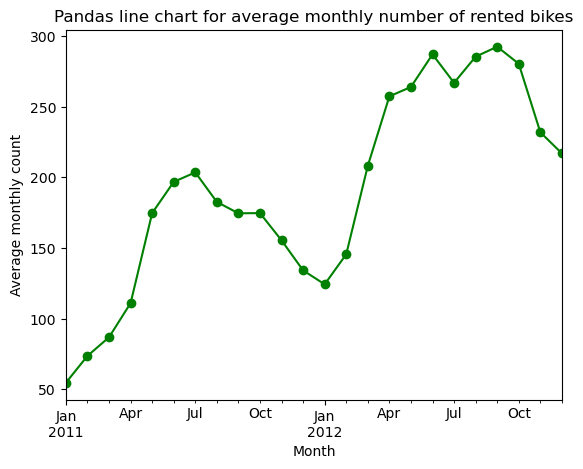

In [12]:
monthly_count.plot(
    marker = 'o',
    color = 'green',
    xlabel = 'Month',
    ylabel = 'Average monthly count',
    title = 'Pandas line chart for average monthly number of rented bikes'
);

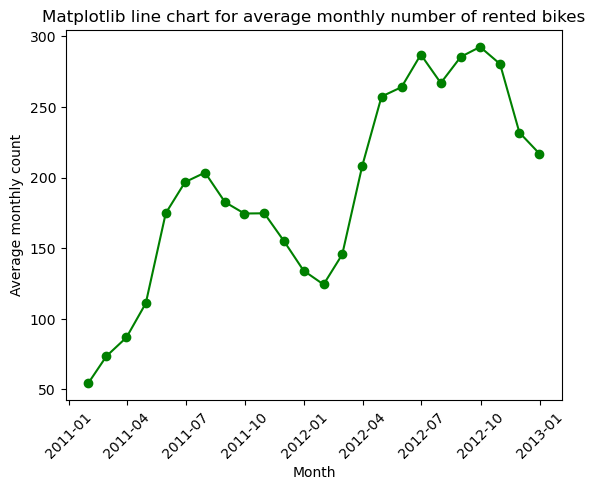

In [19]:
plt.plot (monthly_count, marker = 'o', color = 'green')
plt.title ('Matplotlib line chart for average monthly number of rented bikes')
plt.xlabel ('Month')
plt.ylabel ('Average monthly count')
plt.xticks (rotation = 45);

Графіки відрізняються тим, що дейбли місяців в Matplotlib числові / дати, а в Pandas - словами. Друга відмінність в тому, що в Pandas графік дотикається до меж Axesб а в Matplotlib - ні. Більше подобається варіант Pandas адже він візуально за рахунок похначок місяців легше сприймається.   

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [20]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

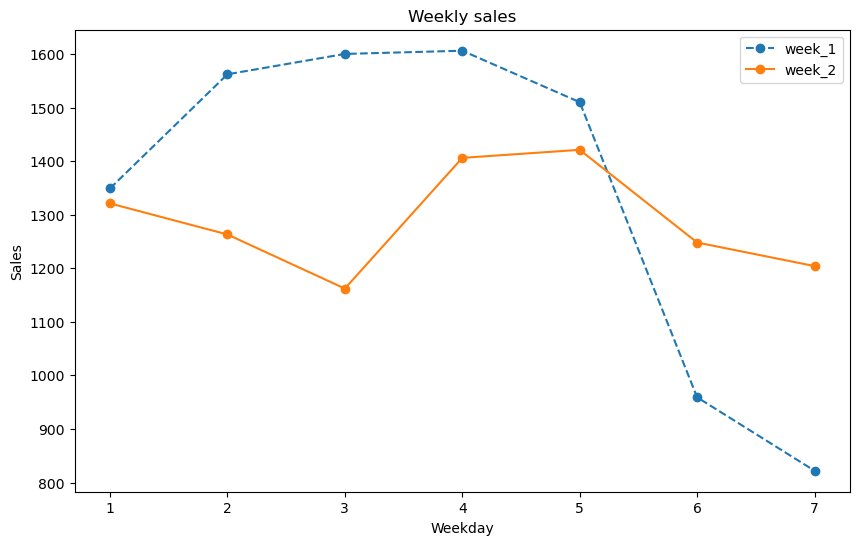

In [26]:
plt.figure (figsize = (10, 6))
plt.plot (days, sales_week1, 'o--', label = 'week_1')
plt.plot (days, sales_week2, 'o-', label = 'week_2')

plt.title ('Weekly sales')
plt.legend ()
plt.ylabel ('Sales')
plt.xlabel ('Weekday');

1. Продажі були стабільнішими на другому тижні. Протягом першого тижня був різкий спад продажів на вихідних.
2. Висновок про стабідьність, наприклад чим більший діапазон значень між max and min значеннями, тим менш стабільні продажі. так само чим більше стандартне відхилення тим менш стабільні показники.

In [27]:
# розрахунки через numpy

std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

range_week1 = max(sales_week1) - min(sales_week1)
range_week2 = max(sales_week2) - min(sales_week2)

print("STD Week1:", std_week1)
print("STD Week2:", std_week2)
print("Range Week1:", range_week1)
print("Range Week2:", range_week2)

STD Week1: 299.99857142517004
STD Week2: 90.9060964256355
Range Week1: 784
Range Week2: 259


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [28]:
# середня температура помісячно
monthly_av_temp = df ['temp'].resample ('ME'). mean ()
monthly_av_temp

datetime
2011-01-31     8.633782
2011-02-28    11.331076
2011-03-31    14.063184
2011-04-30    17.776879
2011-05-31    21.528596
2011-06-30    28.191096
2011-07-31    29.967763
2011-08-31    29.667456
2011-09-30    25.141236
2011-10-31    20.903692
2011-11-30    16.036754
2011-12-31    12.897018
2012-01-31    10.987638
2012-02-29    12.256747
2012-03-31    17.704791
2012-04-30    19.661938
2012-05-31    23.819561
2012-06-30    25.937895
2012-07-31    31.715658
2012-08-31    29.805921
2012-09-30    26.412632
2012-10-31    20.963947
2012-11-30    14.332879
2012-12-31    14.765395
Freq: ME, Name: temp, dtype: float64

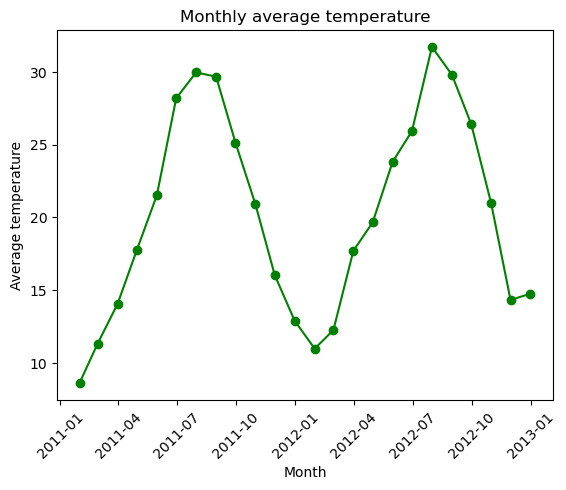

In [47]:
# Лінійний графік середньої температури помісячно
plt.plot (monthly_av_temp, 'o-g')
plt.title ('Monthly average temperature')
plt.xlabel ('Month')
plt.ylabel ('Average temperature')
plt.xticks (rotation = 45);

In [36]:
# середня годинна кількість оренд за кварталами
hourly_avg = df.groupby (['season', 'hour']) ['count'].mean ()
hourly_avg

season  hour
1       0        28.292035
        1        18.761062
        2        13.205607
        3         7.760417
        4         3.336634
                   ...    
4       19      299.359649
        20      214.561404
        21      162.877193
        22      126.412281
        23       89.298246
Name: count, Length: 96, dtype: float64

In [40]:
# середня годинна кількість оренд за кварталами за допомогою pivot table
hourly_pivot = pd.pivot_table(
    df,
    values='count',      # що агрегуємо
    index='hour',        # рядки = години
    columns='season',    # колонки = квартали
    aggfunc='mean'       # беремо середнє
)
hourly_pivot

season,1,2,3,4
hour,,,,
0,28.292035,58.473684,75.675439,57.877193
1,18.761062,35.640351,44.831858,36.166667
2,13.205607,23.482456,31.707965,22.684211
3,7.760417,11.714286,15.778761,11.169643
4,3.336634,6.628319,8.087719,7.228070
5,10.300000,20.377193,25.728070,22.333333
6,42.725664,82.982456,96.780702,82.254386
7,124.433628,232.263158,264.035088,230.956140
8,253.345133,390.192982,403.508772,403.070175


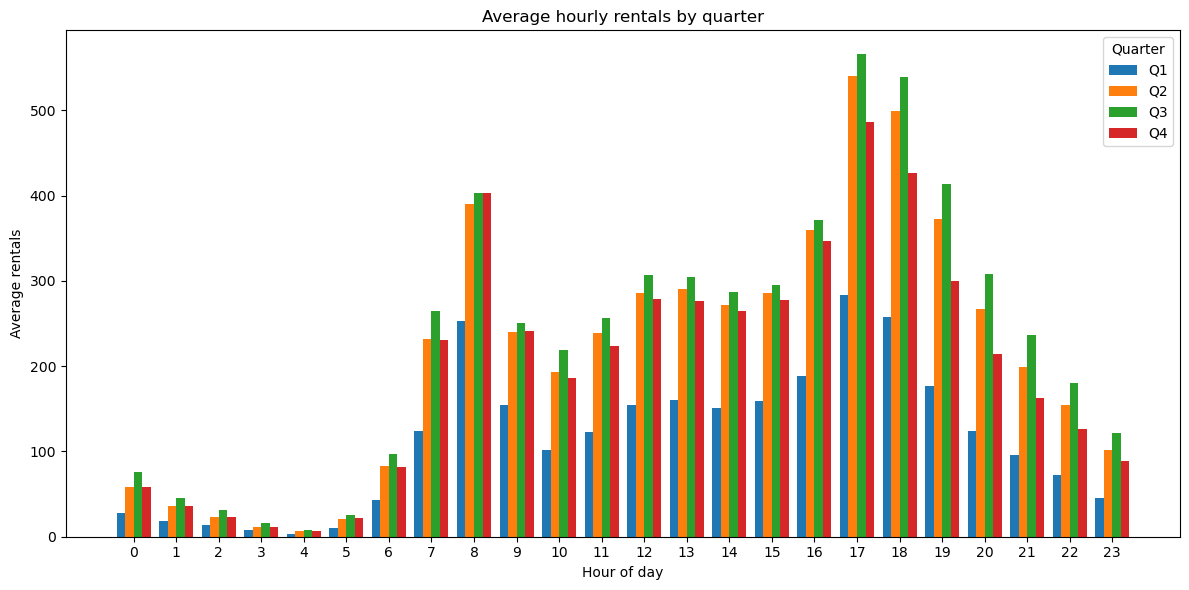

In [42]:
# Стовпчикова діаграма середньої годинної кількості оренд за кварталами

# Дані з pivot table витягуємо години в масив numpy, створюємо позиції по осі Х 
hours = hourly_pivot.index.to_numpy()
x = np.arange(len(hours))

n = len(hourly_pivot.columns)   # кількість кварталів
width = 0.8 / n                 # автоматична ширина (80% ширини години)

plt.figure(figsize=(12, 6))

for i, col in enumerate(hourly_pivot.columns):
    offset = (i - (n-1)/2) * width
    plt.bar(
        x + offset,
        hourly_pivot[col].to_numpy(),
        width=width,
        label=f"Q{col}"
    )

plt.xticks(x, hours)
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Average hourly rentals by quarter")
plt.legend(title="Quarter")

plt.tight_layout()
plt.show()

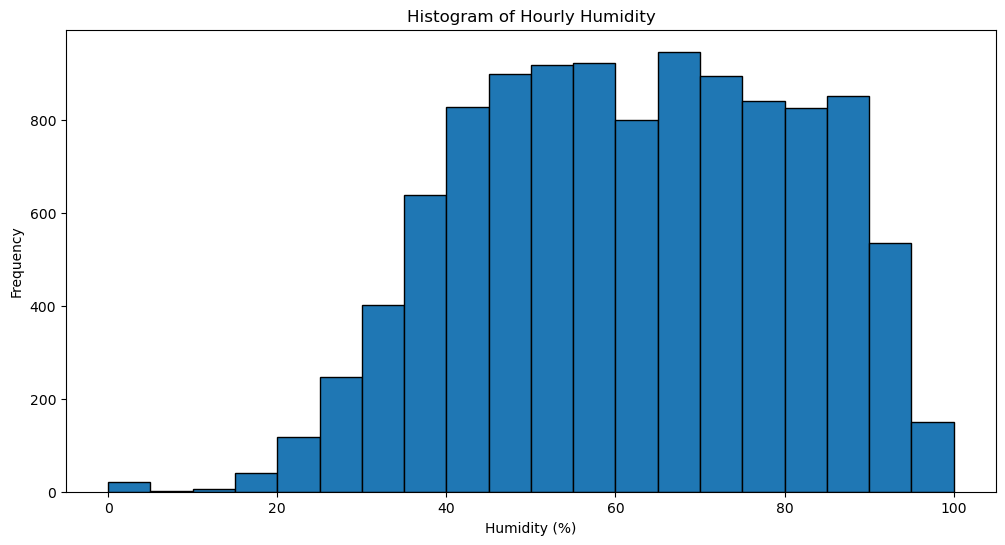

In [44]:
# гістограма вологості

plt.figure(figsize=(12,6))

plt.hist(df['humidity'], bins=20, edgecolor = 'black')

plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.title("Histogram of Hourly Humidity")

plt.show()

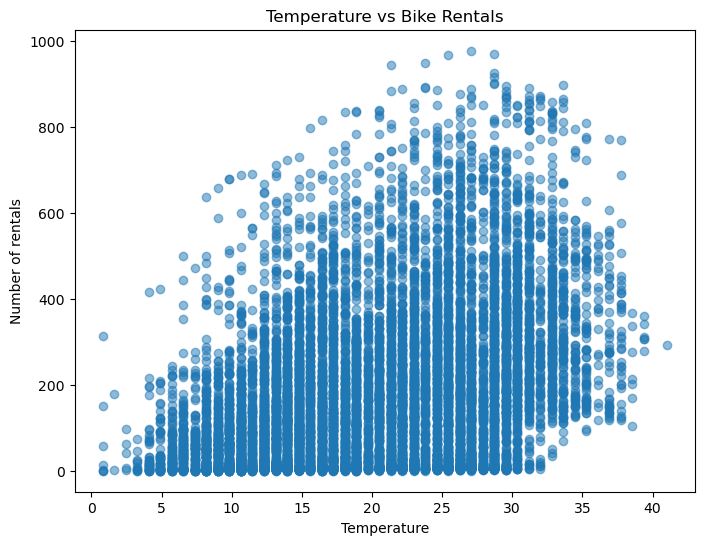

In [45]:
# Scatter plot температури vs кількості оренд
plt.figure(figsize=(8,6))

plt.scatter(df['temp'], df['count'], alpha=0.5)

plt.xlabel("Temperature")
plt.ylabel("Number of rentals")
plt.title("Temperature vs Bike Rentals")

plt.show()

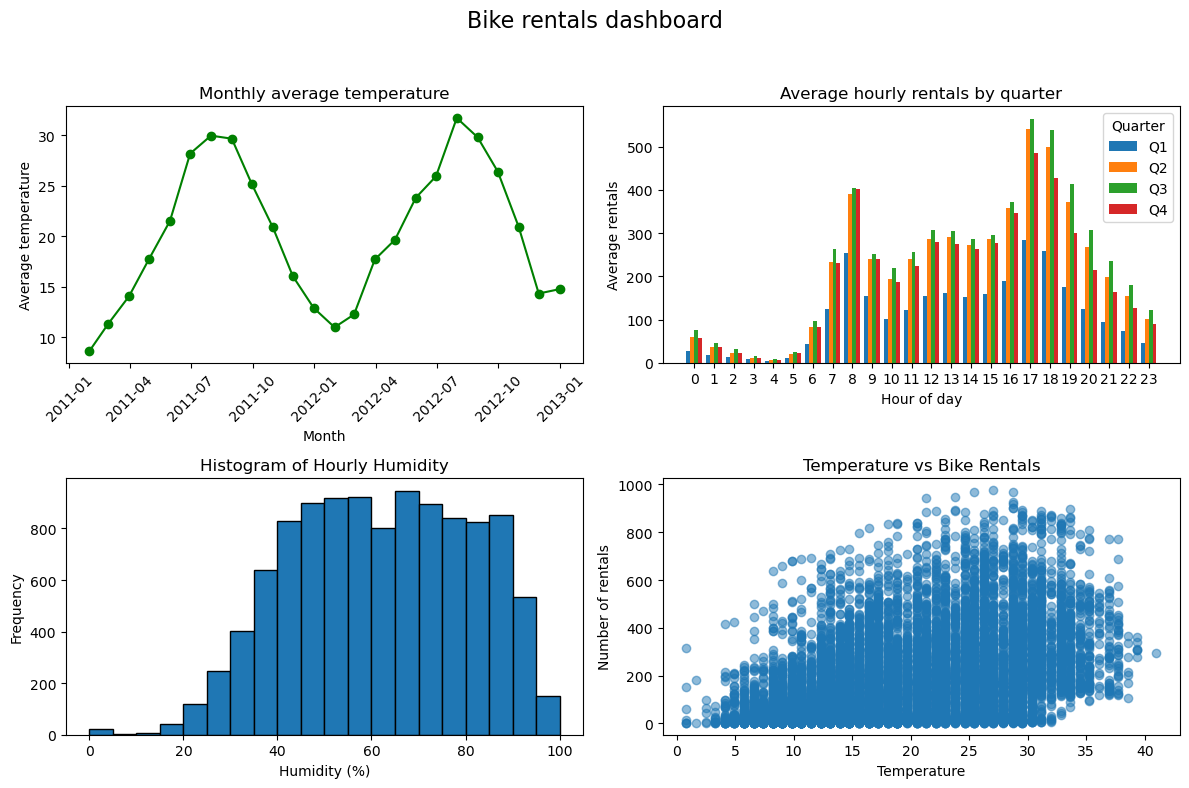

In [49]:
plt.figure(figsize=(12, 8))

# Лінійний графік середньої температури помісячно
plt.subplot (2, 2, 1)
plt.plot (monthly_av_temp, 'o-g')
plt.title ('Monthly average temperature')
plt.xlabel ('Month')
plt.ylabel ('Average temperature')
plt.xticks (rotation = 45);

# Стовпчикова діаграма середньої годинної кількості оренд за кварталами
plt.subplot (2, 2, 2)
for i, col in enumerate(hourly_pivot.columns):
    offset = (i - (n-1)/2) * width
    plt.bar(
        x + offset,
        hourly_pivot[col].to_numpy(),
        width=width,
        label=f"Q{col}"
    )

plt.xticks(x, hours)
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Average hourly rentals by quarter")
plt.legend(title="Quarter")

plt.tight_layout();

# гістограма вологості
plt.subplot (2, 2, 3)
plt.hist(df['humidity'], bins=20, edgecolor = 'black')

plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.title("Histogram of Hourly Humidity");

# Scatter plot температури vs кількості оренд
plt.subplot (2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.5)

plt.xlabel("Temperature")
plt.ylabel("Number of rentals")
plt.title("Temperature vs Bike Rentals");

# Заголовок всієї фігури
plt.suptitle('Bike rentals dashboard', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

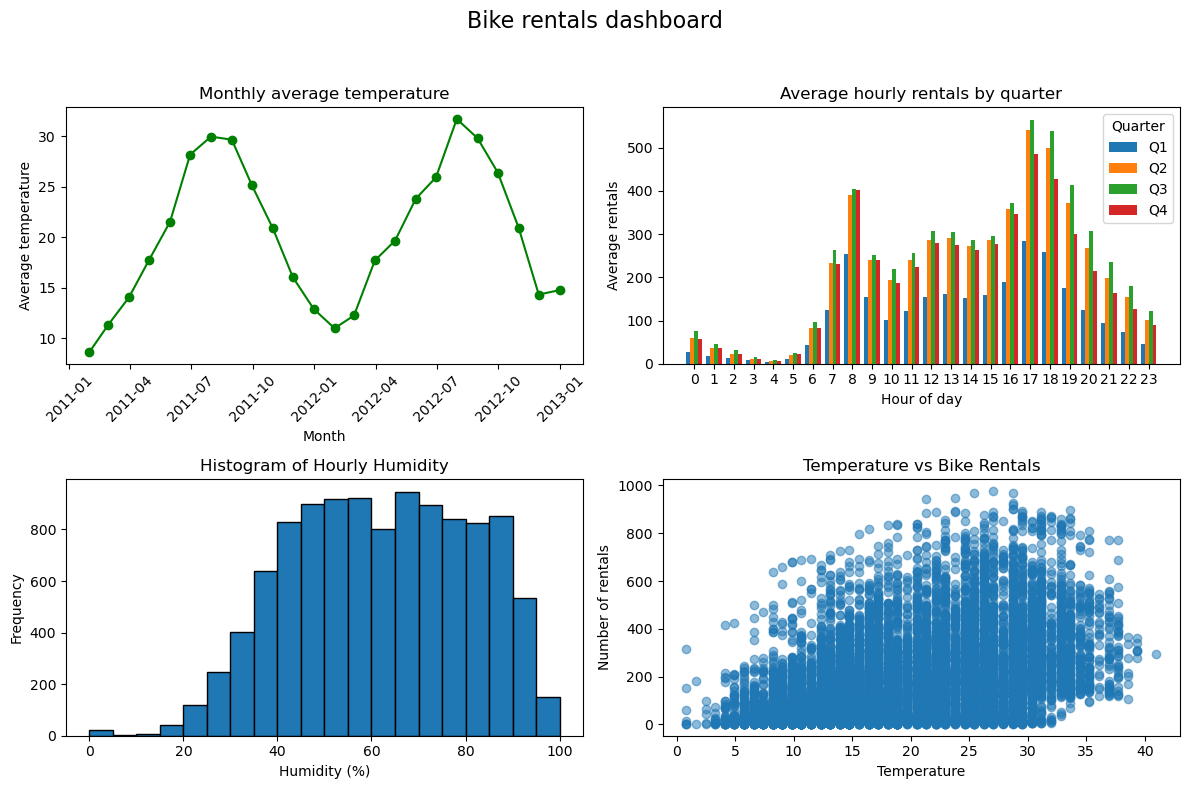

In [57]:
fig, ax = plt.subplots (2, 2, figsize=(12, 8))

# Лінійний графік середньої температури помісячно
ax [0,0].plot (monthly_av_temp, 'o-g')
ax [0,0].set_title ('Monthly average temperature')
ax [0,0].set_xlabel ('Month')
ax [0,0].set_ylabel ('Average temperature')
ax [0,0].tick_params(axis='x', rotation=45);

# Стовпчикова діаграма середньої годинної кількості оренд за кварталами

for i, col in enumerate(hourly_pivot.columns):
    offset = (i - (n - 1) / 2) * width
    ax [0,1].bar(
        x + offset,
        hourly_pivot[col].to_numpy(),
        width=width,
        label=f"Q{col}"
    )
ax [0,1].set_xticks(x)
ax [0,1].set_xticklabels(hours)
ax [0,1].set_xlabel("Hour of day")
ax [0,1].set_ylabel("Average rentals")
ax [0,1].set_title("Average hourly rentals by quarter")
ax [0,1].legend(title="Quarter");

# гістограма вологості
ax [1,0].hist (df['humidity'], bins=20, edgecolor = 'black')
ax [1,0].set_xlabel("Humidity (%)")
ax [1,0].set_ylabel("Frequency")
ax [1,0].set_title("Histogram of Hourly Humidity");

# Scatter plot температури vs кількості оренд
ax [1,1].scatter(df['temp'], df['count'], alpha=0.5)

ax [1,1].set_xlabel("Temperature")
ax [1,1].set_ylabel("Number of rentals")
ax [1,1].set_title("Temperature vs Bike Rentals");

# Заголовок всієї фігури
fig.suptitle('Bike rentals dashboard', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.subplot() — це спосіб створення кількох графіків, де ти кожного разу “активуєш” потрібну область і малюєш у ній. 
plt.subplots() —  підхід, який одразу створює фігуру та набір осей (fig, axes), з якими можна працювати напряму.
Цей спосіб зручніший для складних дашбордів, бо дає більше контролю над кожним графіком і лейаутом.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [58]:
monthly_measures = df ['count'].resample('ME').agg(['mean', 'max', 'min'])
monthly_measures

,mean,max,min
datetime,,,
2011-01-31,54.645012,219,1
2011-02-28,73.641256,327,1
2011-03-31,86.849776,332,1
2011-04-30,111.026374,452,1
2011-05-31,174.809211,611,1
2011-06-30,196.877193,638,1
2011-07-31,203.614035,596,1
2011-08-31,182.666667,600,1
2011-09-30,174.622517,628,1


Text(0.02, 0.95, 'General range: 1 - 977\nStandard deviation: 71')

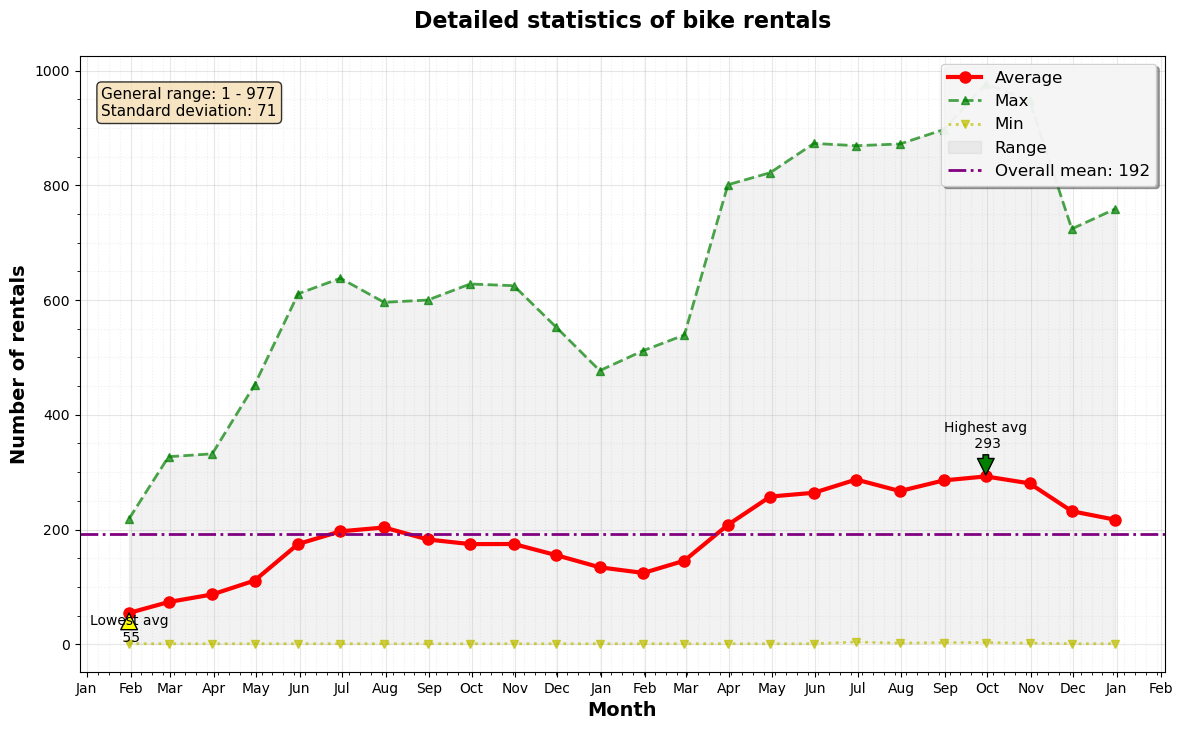

In [88]:
fig, ax = plt.subplots(figsize=(14, 8))

# Малюємо лінії з різними стилями
ax.plot(monthly_measures.index, monthly_measures['mean'], 'r-o', linewidth=3,
        label='Average', markersize=8)
ax.plot(monthly_measures.index, monthly_measures['max'], 'g--^', linewidth=2,
        label='Max', markersize=6, alpha=0.7)
ax.plot(monthly_measures.index, monthly_measures['min'], 'y:v', linewidth=2,
        label='Min', markersize=6, alpha=0.7)

# Заливка між max та min
ax.fill_between(monthly_measures.index, monthly_measures['min'], monthly_measures['max'],
                alpha=0.1, color='gray', label='Range')

# Додаємо анотації для екстремальних значень

max_value = monthly_measures['mean'].max()
min_value = monthly_measures['mean'].min()

max_index = monthly_measures['mean'].idxmax()
min_index = monthly_measures['mean'].idxmin()

ax.annotate(
    f'Highest avg\n {max_value:.0f}',
    xy=(max_index, max_value),
    xytext=(max_index, max_value + 50),
    arrowprops=dict(facecolor='green', shrink=0.05),
    ha='center'
)

ax.annotate(
    f'Lowest avg\n {min_value:.0f}',
    xy=(min_index, min_value),
    xytext=(min_index, min_value - 50),
    arrowprops=dict(facecolor='yellow', shrink=0.05),
    ha='center'
)

# Додаємо середню лінію за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Overall mean: {overall_mean:.0f}')

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Налаштування осей
ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of rentals', fontsize=14, fontweight='bold')
ax.set_title('Detailed statistics of bike rentals',
             fontsize=16, fontweight='bold', pad=20)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Додаємо текст з додатковою статистикою
textstr = f"General range: {monthly_measures['min'].min():.0f} - {monthly_measures['max'].max():.0f}\n"
textstr += f"Standard deviation: {monthly_measures['mean'].std():.0f}"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)

ax.text(
    0.02, 0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=props
)

In [74]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

1. Додавання анотацій на графік допомагає в інтерпретаціїї візуалізаціїї даних, щляхом конкретного вказання на важливі показники, акценти
2. fill_between() показує розкид навколо тренду, коли лінія показує тренд. Це додає глибину аналізу.
3. Текстовий блок допомагає в інтерпретації даних завдяки швидкому summary, Графік стає "self-explanatory", підходить для менеджерського рівня